In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from shapely import wkb
# this is used to cache function return values
# here specifically: SQL query text --> return value
from joblib import Memory 

# custom code
from utilities import run_sql

In [41]:
# Query the database to receive the outlines of administrative regions in Germany. (Europe available!)
df_trips = run_sql('trips', params={'limit': '500000'}) # double percent gets interpreted as single percent in SQL Query
df_trips['energy'] = df_trips['distance'] / 1000
df_trips

________________________________________________________________________________
[Memory] Calling utilities.run_sql_query...
run_sql_query('select * from spirite.anon_master limit %(limit)s;', params={'limit': '500000'})
____________________________________________________run_sql_query - 3.6s, 0.1min


,track_id_new,vehicle_id_anon,tour_id,start_time,stop_time,distance,track_gap,avg_speed,max_speed,n_signal_loss,d_signal_loss,r_signal_loss,avg_hdop,home_base,long_haul,rest_area,service_area_fuel,industrial_area,cid,energy
0,0,1,0,2021-09-10 11:04:53.598000+02:00,2021-09-10 12:07:57.395000+02:00,30751.0,NaN,8.13,20.58,0.0,0.0,0.000000,0.612354,False,False,False,False,True,149,30.751
1,1,1,0,2021-09-10 12:57:54.718000+02:00,2021-09-10 13:13:53.221000+02:00,7762.0,37.504057,8.10,21.79,0.0,0.0,0.000000,1.230128,False,False,False,False,True,-1,7.762
2,2,1,0,2021-09-10 13:25:20.146000+02:00,2021-09-10 14:09:50.802000+02:00,19432.0,4.895394,7.28,24.75,0.0,0.0,0.000000,0.549358,True,False,False,False,True,0,19.432
3,3,1,1,2021-09-10 14:21:35.547000+02:00,2021-09-10 14:25:26.391000+02:00,56.0,3.836167,0.24,2.44,0.0,0.0,0.000000,0.852446,True,False,False,False,True,0,0.056
4,4,1,1,2021-09-10 15:39:48.925000+02:00,2021-09-10 15:45:05.392000+02:00,201.0,12.816326,0.64,3.80,0.0,0.0,0.000000,0.656429,True,False,False,False,True,0,0.201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151593,151593,163,18999,2024-01-05 15:43:20.638000+01:00,2024-01-05 15:43:29.893000+01:00,48.0,399.688607,5.19,11.93,37.0,0.0,0.000000,5.788163,False,False,False,False,False,825,0.048
151594,151594,163,18999,2024-01-08 16:09:28.961000+01:00,2024-01-08 16:24:28.879000+01:00,4985.0,55070.176671,5.54,22.39,18.0,5.0,0.001003,1.310957,True,False,False,False,False,809,4.985
151595,151595,163,19000,2024-01-09 18:04:37.533000+01:00,2024-01-09 18:05:44.141000+01:00,71.0,44965.860287,1.07,5.66,13.0,0.0,0.000000,2.008971,False,False,False,False,True,928,0.071
151596,151596,163,19000,2024-01-10 20:03:12.276000+01:00,2024-01-10 20:03:21.877000+01:00,40.0,41676.863708,4.17,10.71,16.0,0.0,0.000000,4.051362,False,False,False,False,False,-1,0.040


In [48]:
df_fleet = run_sql('fleet', index_col='vehicle_id') # double percent gets interpreted as single percent in SQL Query

df_fleet


________________________________________________________________________________
[Memory] Calling utilities.run_sql_query...
run_sql_query(('SELECT vehicle_id_anon as vehicle_id, fleet_test_id_anon as fleet_test_id, \n'
 '                        gross_vehicle_weight,\n'
 '                        total_mass_with_trailer,\n'
 '                        axle_class\n'
 '                       from spirite.anon_vehicle_id'), index_col='vehicle_id')
____________________________________________________run_sql_query - 0.0s, 0.0min


,fleet_test_id,gross_vehicle_weight,total_mass_with_trailer,axle_class
vehicle_id,,,,
1,1,18000.0,40000.0,98.0
2,1,18000.0,40000.0,98.0
3,1,18000.0,40000.0,98.0
4,1,18000.0,40000.0,98.0
5,1,18000.0,40000.0,98.0
...,...,...,...,...
159,6,18000.0,40000.0,98.0
160,6,18000.0,40000.0,98.0
161,6,18000.0,40000.0,98.0


In [42]:

df_grouped = df_trips.groupby(['tour_id', 'vehicle_id_anon']).agg(
    {'energy': 'sum',
      'distance': 'mean'}).reset_index()
df_grouped

,tour_id,vehicle_id_anon,energy,distance
0,0,1,57.945,19315.000000
1,1,1,0.371,53.000000
2,2,1,36.554,4569.250000
3,3,1,6.757,64.971154
4,4,1,1291.041,80690.062500
...,...,...,...,...
19113,18996,163,1005.350,59138.235294
19114,18997,163,401.422,80284.400000
19115,18998,163,0.507,507.000000
19116,18999,163,422.379,35198.250000


,tour_id,vehicle_id_anon,energy,distance,public,private
0,0,1,57.945,19315.000000,0.000,57.945
1,1,1,0.371,53.000000,0.000,0.371
2,2,1,36.554,4569.250000,0.000,36.554
3,3,1,6.757,64.971154,0.000,6.757
4,4,1,1291.041,80690.062500,791.041,500.000
...,...,...,...,...,...,...
19113,18996,163,1005.350,59138.235294,505.350,500.000
19114,18997,163,401.422,80284.400000,0.000,401.422
19115,18998,163,0.507,507.000000,0.000,0.507
19116,18999,163,422.379,35198.250000,0.000,422.379


In [106]:
df_fleet.fleet_test_id.value_counts()

fleet_test_id
6    97
1    18
4    18
5    13
3    12
2     5
Name: count, dtype: int64

Capcity 300, total public charging: 695047.0310000001, total private charging: 1506410.2249999999
Capcity 400, total public charging: 552626.0349999999, total private charging: 1648831.2210000001
Capcity 500, total public charging: 455088.564, total private charging: 1746368.6919999998


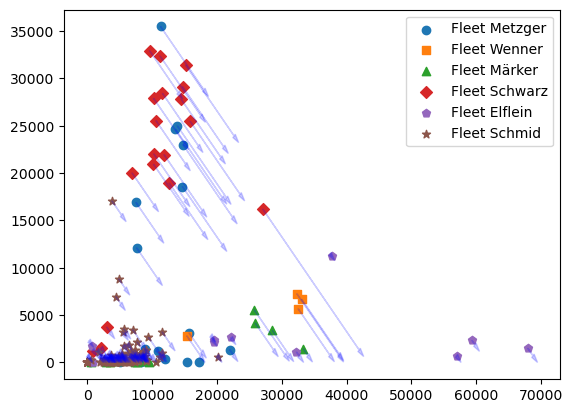

In [ ]:
SPEDITIONEN = {1: 'Metzger',
               2: 'Wenner',
               3: 'Märker',
               4: 'Schwarz',
               5: 'Elflein',
               6: 'Schmid'}

for BATT_CAP in [300,400,500]:
  df_grouped['public'] = (df_grouped['energy'] - BATT_CAP).apply(lambda x: max(0, x))
  df_grouped['private'] = df_grouped['energy'].apply(lambda energy: min(energy, BATT_CAP))
  df_grouped_cluster = df_grouped.groupby('vehicle_id_anon').agg(
      {'private': 'sum',
        'public': 'sum'})#.reset_index()
  df_grouped_cluster = df_grouped_cluster.join(df_fleet, on='vehicle_id_anon', how='inner')
  if BATT_CAP == 300:
    df_grouped_cluster_300 = df_grouped_cluster
    unique_fleet_ids = df_grouped_cluster['fleet_test_id'].unique()
    markers = ['o', 's', '^', 'D', 'p', '*', 'H', '+', 'x', '|', '_']  # List of possible markers
        
    for fleet_id, marker in zip(unique_fleet_ids, markers):
          fleet_data = df_grouped_cluster[df_grouped_cluster['fleet_test_id'] == fleet_id]
          plt.scatter(fleet_data['private'], fleet_data['public'], 
                      label=f'Fleet {SPEDITIONEN[fleet_id]}', marker=marker)

  if BATT_CAP == 500:
    df_grouped_cluster_500 = df_grouped_cluster
  print(f"Capcity {BATT_CAP}, total public charging: {df_grouped['public'].sum()}, total private charging: {df_grouped['private'].sum()}")

plt.legend()


# Loop over the values of df_grouped_cluster_300 and df_grouped_cluster_500
for i in range(len(df_grouped_cluster_300)):
    plt.arrow(
        df_grouped_cluster_300['private'].iloc[i],
        df_grouped_cluster_300['public'].iloc[i],
        df_grouped_cluster_500['private'].iloc[i] - df_grouped_cluster_300['private'].iloc[i],
        df_grouped_cluster_500['public'].iloc[i] - df_grouped_cluster_300['public'].iloc[i],
        head_width=500, head_length=1000, fc='blue', ec='blue', length_includes_head=True, alpha=0.2
    )

plt.show()
#shape='full', color='b', lw=1, length_includes_head=True, 
#zorder=0, head_length=3., head_width=1.5


In [ ]:
display(df_grouped_cluster_300['private'])
display(df_grouped_cluster_300['public'])
display(df_grouped_cluster_500['private'])
display(df_grouped_cluster_300['private'],)

vehicle_id_anon
1       7589.261
2       8925.250
3      15680.755
4      10879.637
5       8237.870
         ...    
159    20213.535
160     7378.180
161     4394.315
162     8339.735
163     6989.784
Name: private, Length: 163, dtype: float64

vehicle_id_anon
1      12119.041
2        103.787
3       3135.042
4       1233.781
5          0.000
         ...    
159      566.585
160      933.820
161      140.880
162      921.284
163     3464.360
Name: public, Length: 163, dtype: float64

vehicle_id_anon
1      11589.261
2       9029.037
3      18361.886
4      12086.649
5       8237.870
         ...    
159    20780.120
160     8099.405
161     4535.195
162     9186.820
163     9193.665
Name: private, Length: 163, dtype: float64

vehicle_id_anon
1       7589.261
2       8925.250
3      15680.755
4      10879.637
5       8237.870
         ...    
159    20213.535
160     7378.180
161     4394.315
162     8339.735
163     6989.784
Name: private, Length: 163, dtype: float64

In [77]:
if df_grouped_cluster_300.private:
    print("True")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().